In [105]:
import numpy as np
import random

def generate_maze(n):
    """
    Generate a perfect maze using recursive backtracking.
    n = number of cells per side. Grid size = (2n+1) x (2n+1), e.g. n=25 -> 51x51.
    All open cells are guaranteed connected. Start/goal chosen separately.
    """
    size = 2 * n + 1
    maze = np.ones((size, size), dtype=int)

    def carve(r, c):
        dirs = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr, nc = r + dr, c + dc
            if 0 <= nr < n and 0 <= nc < n and maze[2*nr+1][2*nc+1] == 1:
                maze[2*r+1 + dr][2*c+1 + dc] = 0
                maze[2*nr+1][2*nc+1] = 0
                carve(nr, nc)

    maze[1][1] = 0
    carve(0, 0)
    return maze


def random_start_goal(maze, min_dist=10):
    """Pick two distinct open cells at least min_dist Manhattan distance apart."""
    open_cells = list(zip(*np.where(maze == 0)))
    while True:
        s, g = random.sample(open_cells, 2)
        if abs(s[0] - g[0]) + abs(s[1] - g[1]) >= min_dist:
            return tuple(s), tuple(g)

Generated 15x15 maze  |  start=(np.int64(13), np.int64(11))  goal=(np.int64(1), np.int64(9))  dist=14


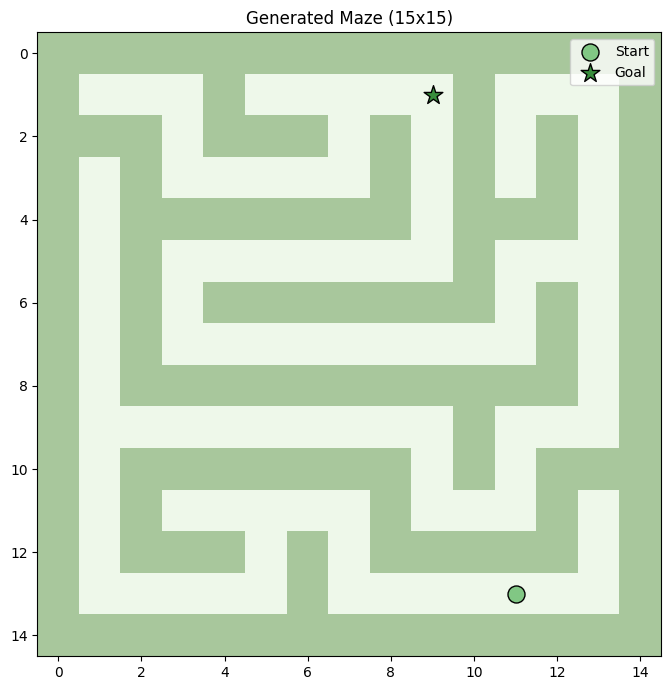

Appended to 'mazes.txt'


In [106]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- Parameters ---
n          = 7       # cells per side — maze grid will be (2n+1) x (2n+1), e.g. n=24 -> 49x49
min_dist   = 10       # minimum Manhattan distance between start and goal
output_file = "mazes.txt"
# ------------------

maze = generate_maze(n)
size = maze.shape[0]
start, goal = random_start_goal(maze, min_dist=min_dist)

print(f"Generated {size}x{size} maze  |  start={start}  goal={goal}  dist={abs(start[0]-goal[0])+abs(start[1]-goal[1])}")

cmap = ListedColormap(['#eef8ea', '#a8c79c'])
plt.figure(figsize=(7, 7))
plt.imshow(maze, cmap=cmap)
plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black', s=150, zorder=5, label='Start')
plt.scatter(goal[1],  goal[0],  marker='*', color='#388e3c', edgecolors='black', s=200, zorder=5, label='Goal')
plt.title(f'Generated Maze ({size}x{size})')
plt.legend()
plt.tight_layout()
plt.show()


# Append maze to text file as a numpy array literal
rows = []
for row in maze:
    rows.append('    [' + ', '.join(str(v) for v in row) + '],')

block = (
    f"# {size}x{size} maze  start={start}  goal={goal}\n"
    f"maze = np.array([\n"
    + '\n'.join(rows) + "\n"
    + "])\n"
    + f"start = {start}\n"
    + f"goal  = {goal}\n"
    + "\n" + "-" * 60 + "\n\n"
)

with open(output_file, 'a') as f:
    f.write(block)

print(f"Appended to '{output_file}'")

In [107]:
# Append maze to text file as a numpy array literal
rows = []
for row in maze:
    rows.append('    [' + ', '.join(str(v) for v in row) + '],')

block = (
    f"# {size}x{size} maze  start={start}  goal={goal}\n"
    f"maze = np.array([\n"
    + '\n'.join(rows) + "\n"
    + "])\n"
    + f"start = {start}\n"
    + f"goal  = {goal}\n"
    + "\n" + "-" * 60 + "\n\n"
)

with open(output_file, 'a') as f:
    f.write(block)

print(f"Appended to '{output_file}'")

Appended to 'mazes.txt'
